In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout

# Caricamento e pulizia rapida
df_t = sns.load_dataset('titanic')

print(df_t.describe())
print(df_t.info())
print(df_t.head())

# Gestione NULLI: riempiamo l'età con la mediana e imbarked con la moda
df_t['age'] = df_t['age'].fillna(df_t['age'].median())
df_t['embarked'] = df_t['embarked'].fillna(df_t['embarked'].mode()[0])
# Eliminiamo colonne ridondanti o con troppi nulli nel caso di deck
df_t = df_t.drop(columns=['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male'])

# Encoding delle variabili categoriche, trasformandole in numeriche.
# keras non sa gestire categoriche
df_t = pd.get_dummies(df_t, drop_first=True)



         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null  

In [ ]:
# Split X e y
X = df_t.drop('survived', axis=1).astype('float32')
y = df_t['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling: normalizzare le feature numeriche. (Fondamentale per le reti neurali)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Modello Keras
'''
model_t = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)), # Layer 1
    Dropout(0.2),                                                # regolarizzazione, Previene overfitting, viene spento il 20% dei neuroni del layer ad ogni batch
    Dense(16, activation='relu'),                                # Layer 2
    Dense(1, activation='sigmoid')                               # OUTPUT: Classificazione binaria
])'''


model_t = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

model_t.summary()

model_t.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
#model_t.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

from keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=7, 
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


history = model_t.fit(X_train, y_train,
                    epochs=50, #20
                    batch_size=32,
                    validation_split=0.15,
                    callbacks=[early_stop, reduce_lr],
                    verbose=1
                    )

print(f"Titanic Accuracy: {model_t.evaluate(X_test, y_test, verbose=0)[1]:.4f}")


C:\Users\elisabetta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,649 (45.50 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6727 - loss: 0.6492 - val_accuracy: 0.8411 - val_loss: 0.5673
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7769 - loss: 0.5502 - val_accuracy: 0.8318 - val_loss: 0.4372
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7901 - loss: 0.4967 - val_accuracy: 0.8318 - val_loss: 0.3643
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7967 - loss: 0.4755 - val_accuracy: 0.8318 - val_loss: 0.3551
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8033 - loss: 0.4675 - val_accuracy: 0.8411 - val_loss: 0.3576
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8083 - loss: 0.4459 - val_accuracy: 0.8598 - val_loss: 0.3453
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8182 - loss: 0.4403 - val_accuracy: 0.8598 - val_loss: 0.3401
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7967 - loss: 0.4492 - val_accuracy: 0.8411 - val_los

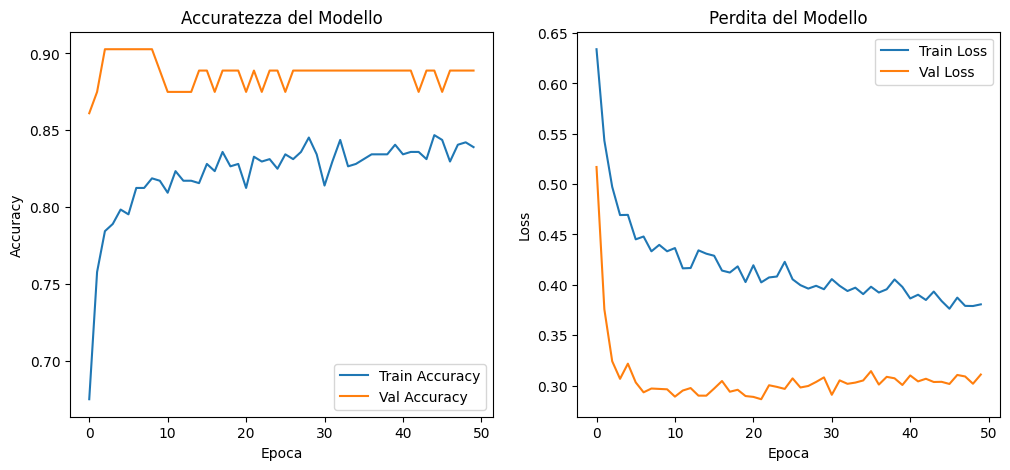

In [24]:
import matplotlib.pyplot as plt

# Creiamo una figura con due grafici (Sottoplot)
plt.figure(figsize=(12, 5))

# Grafico della Precisione (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuratezza del Modello')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()

# Grafico della Perdita (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Perdita del Modello')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [26]:
test_loss, test_accuracy = model_t.evaluate(X_test, y_test)

print(f'Perdita sul test set: {test_loss:.4f}')

print(f'Accuratezza sul test set: {test_accuracy:.4f}')

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8212 - loss: 0.4442
Perdita sul test set: 0.4442
Accuratezza sul test set: 0.8212


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


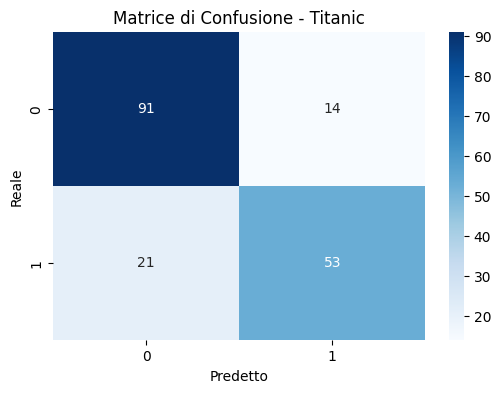

In [16]:
from sklearn.metrics import confusion_matrix

# Otteniamo le predizioni (0 o 1)
y_pred = (model_t.predict(X_test) > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice di Confusione - Titanic')
plt.xlabel('Predetto')
plt.ylabel('Reale')
plt.show()